## Step : Explore Our Data

In [ ]:
from explore import load_sample, inspect_mask, binarize, plot_comparison, polyp_coverage

IMG_DIR  = "data/Kvasir-SEG/images"
MASK_DIR = "data/Kvasir-SEG/masks"

img, mask, name = load_sample(IMG_DIR, MASK_DIR)
inspect_mask(mask)

In [ ]:
binary_mask = binarize(mask)
plot_comparison(img, mask, binary_mask)

In [ ]:
print(f"Polyp coverage: {polyp_coverage(binary_mask):.2%}")

## Step 2: Dataset & DataLoaders

In [1]:
import torch
from dataset import build_dataloaders

IMG_DIR  = "data/Kvasir-SEG/images"
MASK_DIR = "data/Kvasir-SEG/masks"

train_loader, val_loader, test_loader = build_dataloaders(
    img_dir=IMG_DIR,
    mask_dir=MASK_DIR,
    batch_size=8,
    num_workers=2,
)

In [2]:
print(f"Train: {len(train_loader.dataset)} samples, {len(train_loader)} batches")
print(f"Val  : {len(val_loader.dataset)} samples")
print(f"Test : {len(test_loader.dataset)} samples")

imgs, masks = next(iter(train_loader))
print(f"\nImage batch shape : {imgs.shape}   dtype: {imgs.dtype}")
print(f"Mask  batch shape : {masks.shape}  dtype: {masks.dtype}")
print(f"Image value range : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Mask unique values: {masks.unique().tolist()}")

assert imgs.shape  == (8, 3, 256, 256)
assert masks.shape == (8, 1, 256, 256)
assert imgs.dtype  == torch.float32
assert masks.dtype == torch.float32
assert set(masks.unique().tolist()).issubset({0.0, 1.0})
assert len(train_loader.dataset) == 800
assert len(val_loader.dataset)   == 100
assert len(test_loader.dataset)  == 100
print("\nAll assertions passed.")

Train: 800 samples, 100 batches
Val  : 100 samples
Test : 100 samples

Image batch shape : torch.Size([8, 3, 256, 256])   dtype: torch.float32
Mask  batch shape : torch.Size([8, 1, 256, 256])  dtype: torch.float32
Image value range : [-2.118, 2.640]
Mask unique values: [0.0, 1.0]

All assertions passed.


In [3]:
from dataset import split_dataset

train_paths = set(train_loader.dataset.img_paths)
val_paths   = set(val_loader.dataset.img_paths)
test_paths  = set(test_loader.dataset.img_paths)

assert len(train_paths & val_paths)  == 0
assert len(train_paths & test_paths) == 0
assert len(val_paths   & test_paths) == 0
print("No overlap between splits.")

No overlap between splits.


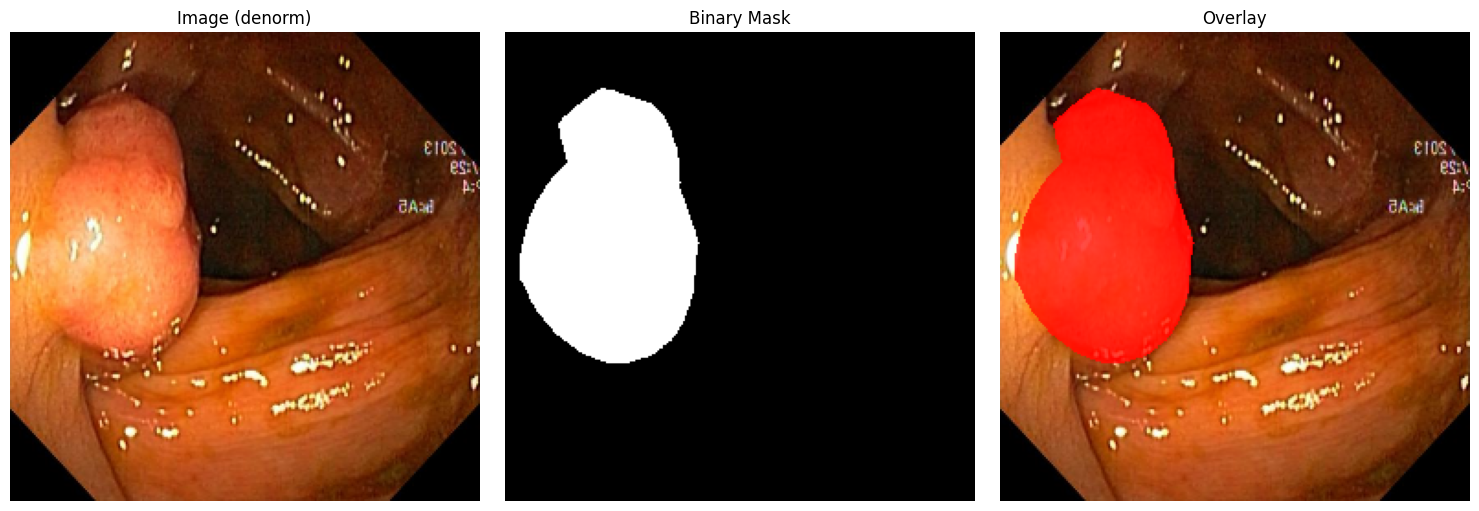

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.numpy().transpose(1, 2, 0)  # [C,H,W] -> [H,W,C]
    return np.clip(img * std + mean, 0, 1)

img_t, mask_t = imgs[0], masks[0]
img_disp  = denormalize(img_t)
mask_disp = mask_t.squeeze().numpy()

overlay = img_disp.copy()
overlay[mask_disp == 1, 0] = 1.0   # red channel max where polyp
overlay[mask_disp == 1, 1] *= 0.3
overlay[mask_disp == 1, 2] *= 0.3

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_disp);             axes[0].set_title("Image (denorm)")
axes[1].imshow(mask_disp, cmap="gray"); axes[1].set_title("Binary Mask")
axes[2].imshow(overlay);              axes[2].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 3: UNet Model

In [ ]:
import torch
from model import UNet

model = UNet(in_channels=3, out_channels=1)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

In [ ]:
dummy = torch.zeros(2, 3, 256, 256)
with torch.no_grad():
    out = model(dummy)

print(f"Input  shape: {dummy.shape}")
print(f"Output shape: {out.shape}")

assert out.shape == (2, 1, 256, 256), f"Unexpected output shape: {out.shape}"
print("Shape assertion passed.")